# <font color="magenta">Lab 1</font>: Introduction to Python for Machine Learning

In [9]:
## import essential packages
import os
import pandas as pd
import numpy as np
import math

## 1. Loading and Analyzing Data

### In this class you will be provided data in the form of csv files. In order to analyze this data in the notebook, you can load these files into a pandas dataframe using the read_csv() function. This will be standard practice. 

In [10]:
## read in the csv data from the correct filepath
PATH = (r"data") # Update this path as necessary; you might need to go up or down a folder depending on how you've set up your repo. 
df_college = pd.read_csv(os.path.join(PATH, 'College.csv'))

Remember to use the best practices you learned in DAP!
   - Set a global PATH statement at the top of your file
   - Use the os library to combine that with files
   - Then anyone working with your code just has to change a single PATH statement!

### After loading dataframes, you typically want to get familiar with what the data looks like and what you have been provided. Here are a few pandas functions you can use to get familiar with your dataframes.

In [11]:
## view the first 5 rows of the dataframe
df_college.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [12]:
## see the name of all the columns
df_college.columns

Index(['Unnamed: 0', 'Private', 'Apps', 'Accept', 'Enroll', 'Top10perc',
       'Top25perc', 'F.Undergrad', 'P.Undergrad', 'Outstate', 'Room.Board',
       'Books', 'Personal', 'PhD', 'Terminal', 'S.F.Ratio', 'perc.alumni',
       'Expend', 'Grad.Rate'],
      dtype='object')

In [13]:
## see the type of each column, and whether it contains nulls
df_college.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   777 non-null    object 
 1   Private      777 non-null    object 
 2   Apps         777 non-null    int64  
 3   Accept       777 non-null    int64  
 4   Enroll       777 non-null    int64  
 5   Top10perc    777 non-null    int64  
 6   Top25perc    777 non-null    int64  
 7   F.Undergrad  777 non-null    int64  
 8   P.Undergrad  777 non-null    int64  
 9   Outstate     777 non-null    int64  
 10  Room.Board   777 non-null    int64  
 11  Books        777 non-null    int64  
 12  Personal     777 non-null    int64  
 13  PhD          777 non-null    int64  
 14  Terminal     777 non-null    int64  
 15  S.F.Ratio    777 non-null    float64
 16  perc.alumni  777 non-null    int64  
 17  Expend       777 non-null    int64  
 18  Grad.Rate    777 non-null    int64  
dtypes: float

In [14]:
## see (# of rows, # of columns)
df_college.shape

(777, 19)

In [15]:
## see summary statistics about each feature (AKA, column)
df_college.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


In [16]:
## flip the output (i.e. reverse the rows and columns)...
df_college.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Apps,777.0,3001.638353,3870.201484,81.0,776.0,1558.0,3624.0,48094.0
Accept,777.0,2018.804376,2451.113971,72.0,604.0,1110.0,2424.0,26330.0
Enroll,777.0,779.972973,929.176190,35.0,242.0,434.0,902.0,6392.0
Top10perc,777.0,27.558559,17.640364,1.0,15.0,23.0,35.0,96.0
Top25perc,777.0,55.796654,19.804778,9.0,41.0,54.0,69.0,100.0
F.Undergrad,777.0,3699.907336,4850.420531,139.0,992.0,1707.0,4005.0,31643.0
P.Undergrad,777.0,855.298584,1522.431887,1.0,95.0,353.0,967.0,21836.0
Outstate,777.0,10440.669241,4023.016484,2340.0,7320.0,9990.0,12925.0,21700.0
Room.Board,777.0,4357.526384,1096.696416,1780.0,3597.0,4200.0,5050.0,8124.0
Books,777.0,549.380952,165.105360,96.0,470.0,500.0,600.0,2340.0


In [17]:
## ... and round to make the table more readable
df_college.describe().transpose().round(3)

,count,mean,std,min,25%,50%,75%,max
Apps,777.0,3001.638,3870.201,81.0,776.0,1558.0,3624.0,48094.0
Accept,777.0,2018.804,2451.114,72.0,604.0,1110.0,2424.0,26330.0
Enroll,777.0,779.973,929.176,35.0,242.0,434.0,902.0,6392.0
Top10perc,777.0,27.559,17.640,1.0,15.0,23.0,35.0,96.0
Top25perc,777.0,55.797,19.805,9.0,41.0,54.0,69.0,100.0
F.Undergrad,777.0,3699.907,4850.421,139.0,992.0,1707.0,4005.0,31643.0
P.Undergrad,777.0,855.299,1522.432,1.0,95.0,353.0,967.0,21836.0
Outstate,777.0,10440.669,4023.016,2340.0,7320.0,9990.0,12925.0,21700.0
Room.Board,777.0,4357.526,1096.696,1780.0,3597.0,4200.0,5050.0,8124.0
Books,777.0,549.381,165.105,96.0,470.0,500.0,600.0,2340.0


In [18]:
## subset and view a single column
#df_college.loc[:, ["PhD"]]
print(df_college['Accept'])

## read section of a column
#print(df_college['Accept'][0:4])

## read multiple columns 
#print(df_college[['Accept','Enroll', 'Outstate']])

0      1232
1      1924
2      1097
3       349
4       146
       ... 
772    1515
773    1805
774    1915
775    2453
776    1855
Name: Accept, Length: 777, dtype: int64


In [19]:
## read multiple columns
df_college.loc[:, ['Unnamed: 0', 'P.Undergrad', 'PhD']]
#print(df_college[['Accept','Enroll', 'Outstate']])

,Unnamed: 0,P.Undergrad,PhD
0,Abilene Christian University,537,70
1,Adelphi University,1227,29
2,Adrian College,99,53
3,Agnes Scott College,63,92
4,Alaska Pacific University,869,76
...,...,...,...
772,Worcester State College,2029,60
773,Xavier University,1107,73
774,Xavier University of Louisiana,166,67
775,Yale University,83,96


In [20]:
# indexing rows and columns at the same time
df_college.loc[[2, 347, 566], ['Unnamed: 0', 'P.Undergrad', "PhD"]]

,Unnamed: 0,P.Undergrad,PhD
2,Adrian College,99,53
347,Mary Washington College,736,75
566,SUNY College at Buffalo,2091,71


## 2. Data Cleaning and Engineering

### Arguably, the most time consuming aspect of machine learning is data cleaning. Moreover, depending on the context of the problem, there are many subjective decisions that you will have to consider (for example, how to handle null values, selecting which columns to consider in your analysis, engineering new information from the existing data, etc.). You will learn a lot more about this throughout the quarter. 

### For now, here are a few basic functions/operations that will be useful for the cleaning and manipulating dataframes. This is only a short list for now to get you familiar with the process - The labs each week will cover these techniques more thouroughly and give you more tools throughout the quarter. 

In [21]:
# rename a column
df_college.rename(columns={'Unnamed: 0': 'Name'}, inplace=True)
df_college.head()

,Name,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [22]:
## Drop the NA values (note that here the output is not saved)
df_college.dropna()
df_college.head()
#print(college.shape)

,Name,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [23]:
## create dummy variables
## for example, convert the column "Private" into 1 for "Yes" and 0 for "No"
df_college['Private'] = np.where(df_college['Private'] == "Yes", 1, 0)
df_college.head()

,Name,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,1,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,1,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,1,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,1,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,1,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [24]:
# create new columns based on a condition
# for example, create a new column 'The Best' which will be "Yes" if there are over 50 students in the admitted class who are from the 
# top 10% of their high school classes
df_college['The.Best'] = np.where(df_college['Top10perc'] > 50,'Yes','No')
df_college.head()

,Name,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate,The.Best
0,Abilene Christian University,1,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60,No
1,Adelphi University,1,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56,No
2,Adrian College,1,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54,No
3,Agnes Scott College,1,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59,Yes
4,Alaska Pacific University,1,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15,No


In [25]:
# engineer new columns using information from existing columns, part 1
# for example, create a new column called "Acceptance.Rate" which is the ratio of number of accepted students/number of applications
df_college['Acceptance.Rate'] = df_college['Accept'] / df_college['Apps']
df_college.head()

,Name,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate,The.Best,Acceptance.Rate
0,Abilene Christian University,1,1660,1232,721,23,52,2885,537,7440,...,450,2200,70,78,18.1,12,7041,60,No,0.742169
1,Adelphi University,1,2186,1924,512,16,29,2683,1227,12280,...,750,1500,29,30,12.2,16,10527,56,No,0.880146
2,Adrian College,1,1428,1097,336,22,50,1036,99,11250,...,400,1165,53,66,12.9,30,8735,54,No,0.768207
3,Agnes Scott College,1,417,349,137,60,89,510,63,12960,...,450,875,92,97,7.7,37,19016,59,Yes,0.836930
4,Alaska Pacific University,1,193,146,55,16,44,249,869,7560,...,800,1500,76,72,11.9,2,10922,15,No,0.756477


In [26]:
# engineer new columns using information from existing columns, part 2
# for example, square the Acceptance.Rate column
df_college['Acceptance.Rate.squared'] = df_college['Acceptance.Rate'] ** 2
df_college.head()

,Name,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate,The.Best,Acceptance.Rate,Acceptance.Rate.squared
0,Abilene Christian University,1,1660,1232,721,23,52,2885,537,7440,...,2200,70,78,18.1,12,7041,60,No,0.742169,0.550814
1,Adelphi University,1,2186,1924,512,16,29,2683,1227,12280,...,1500,29,30,12.2,16,10527,56,No,0.880146,0.774658
2,Adrian College,1,1428,1097,336,22,50,1036,99,11250,...,1165,53,66,12.9,30,8735,54,No,0.768207,0.590142
3,Agnes Scott College,1,417,349,137,60,89,510,63,12960,...,875,92,97,7.7,37,19016,59,Yes,0.836930,0.700453
4,Alaska Pacific University,1,193,146,55,16,44,249,869,7560,...,1500,76,72,11.9,2,10922,15,No,0.756477,0.572257


In [27]:
# Remove columns from the dataframe, there are 2 ways to do this:
# 1. Delete
del df_college['The.Best']

# 2. Drop
df_college = df_college.drop(['Acceptance.Rate.squared'], axis=1)

df_college.head()

,Name,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate,Acceptance.Rate
0,Abilene Christian University,1,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60,0.742169
1,Adelphi University,1,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56,0.880146
2,Adrian College,1,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54,0.768207
3,Agnes Scott College,1,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59,0.836930
4,Alaska Pacific University,1,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15,0.756477


In [28]:
# Create a subsetted dataframe, there are 2 ways to do this:
# 1. Choose/select columns by name
df_college_subsetted = df_college.loc[:, ["Name", "Private", "Grad.Rate", "Acceptance.Rate"]]
df_college_subsetted.head()

,Name,Private,Grad.Rate,Acceptance.Rate
0,Abilene Christian University,1,60,0.742169
1,Adelphi University,1,56,0.880146
2,Adrian College,1,54,0.768207
3,Agnes Scott College,1,59,0.836930
4,Alaska Pacific University,1,15,0.756477


In [29]:
#2. Drop columns you don't want
df_college_subsetted = df_college_subsetted.drop(["Grad.Rate"], axis=1)
df_college_subsetted.head()

,Name,Private,Acceptance.Rate
0,Abilene Christian University,1,0.742169
1,Adelphi University,1,0.880146
2,Adrian College,1,0.768207
3,Agnes Scott College,1,0.836930
4,Alaska Pacific University,1,0.756477


## 3. Creating Plots and Numerical Summaries

### Creating a Scatterplot: Create a Scatterplot of # of College Applications vs # of Applications Accepted

In [ ]:
#import required libraries
import matplotlib.pyplot as plt
import seaborn as sns

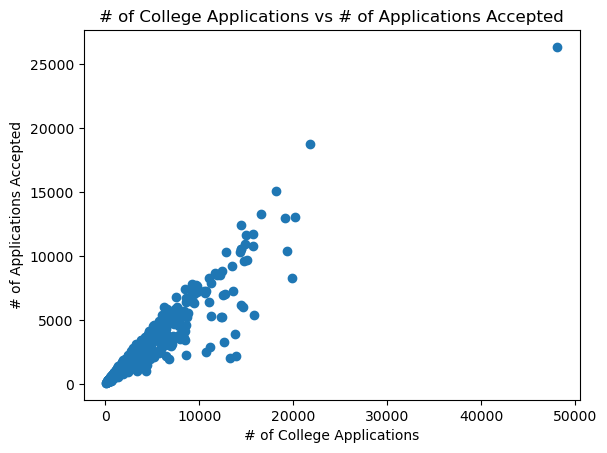

In [ ]:
#https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html#matplotlib.axes.Axes.plot
#https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.scatter.html
fig, ax = plt.subplots()
#ax.plot(df_college['Apps'], df_college['Accept'], 'b.')
ax.scatter(df_college['Apps'], df_college['Accept'])
ax.set_title('# of College Applications vs # of Applications Accepted')
ax.set_xlabel('# of College Applications')
ax.set_ylabel('# of Applications Accepted')
plt.show() 

Remember to use the best practices you learned in DAP!
   - Don't do every operation on the plt object!
   - This is a holdover from the original design based on how Matlab code is written
   - WARNING: It is a very un-Pythonic way to write code!
   - The only places you reference plt are: the initial plt.subplots() function, & the final plt.show() function.

### Creating a Boxplot: Student to Faculty Ratio

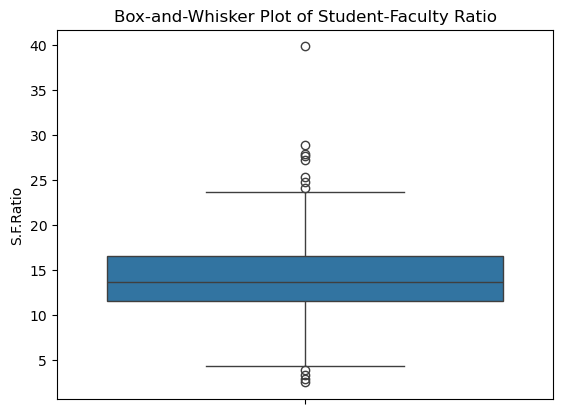

In [ ]:
#https://seaborn.pydata.org/generated/seaborn.boxplot.html
fig, ax = plt.subplots()
ax = sns.boxplot(y="S.F.Ratio", data=df_college) 
ax.set_title('Box-and-Whisker Plot of Student-Faculty Ratio')
plt.show() 

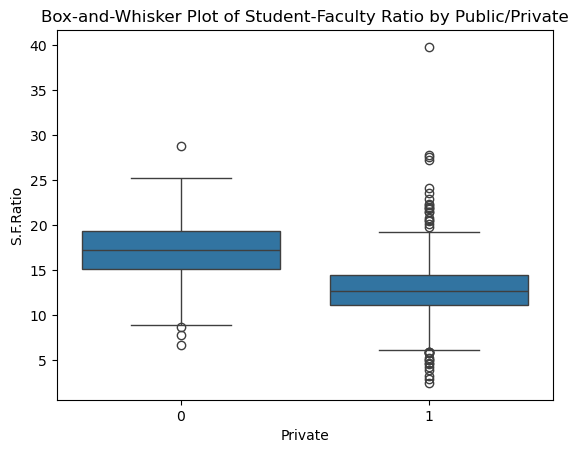

In [ ]:
#https://seaborn.pydata.org/generated/seaborn.boxplot.html
fig, ax = plt.subplots()
sns.boxplot(x="Private", y="S.F.Ratio", data=df_college, ax=ax)  # Adds x variable; uses ax kwarg
ax.set_title('Box-and-Whisker Plot of Student-Faculty Ratio by Public/Private')
plt.show() 

### Creating a Histogram: Graduation Rate of Colleges

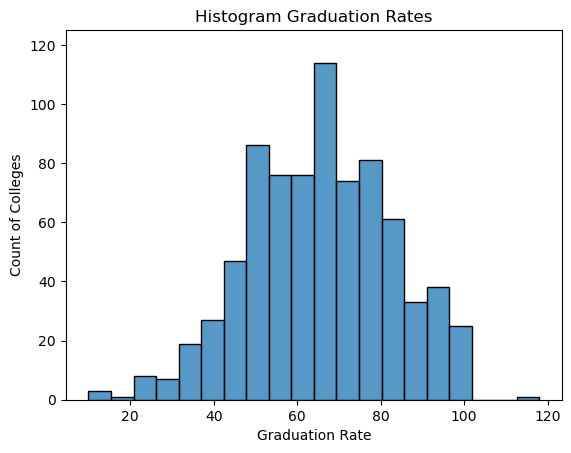

In [ ]:
#https://seaborn.pydata.org/generated/seaborn.histplot.html
fig, ax = plt.subplots()
sns.histplot(data=df_college, x='Grad.Rate', ax=ax)  
ax.set_xlabel('Graduation Rate')
ax.set_ylabel('Count of Colleges')
ax.set_title('Histogram Graduation Rates')
ax.set_ylim(0, 125)
plt.show() 

### Creating a Line Plot: Simulated Data of Undergraduate Enrollment

In [ ]:
from random import seed
from random import randint

np.random.seed(1)
df_college['year'] =  np.random.randint(2010,2020, len(df_college))
df_college2 = df_college.groupby(['year']).mean(numeric_only=True)
df_college2.index.name = 'year'
df_college2.reset_index(inplace=True)

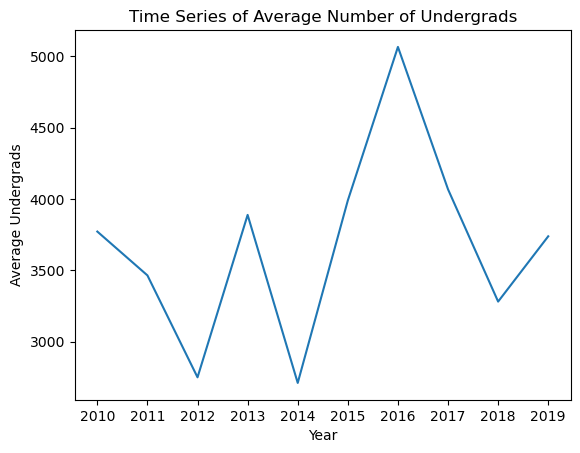

In [ ]:
#https://seaborn.pydata.org/generated/seaborn.lineplot.html
fig, ax = plt.subplots()
#ax.plot(df_college2['year'], df_college2['F.Undergrad'], 'b-')
sns.lineplot(data=df_college2, x='year', y='F.Undergrad', ax=ax)  
ax.set_title('Time Series of Average Number of Undergrads')
ax.set_xlabel('Year')
ax.set_ylabel('Average Undergrads')
ax.set_xticks(range(2010,2020))
plt.show() 

## 3. Python (Text) Files vs. Jupyter Notebooks

Python text files and Jupyter Notebooks are distinct in their ways of writing and displaying code, and each has its place. 

When running Jupyter Notebooks, be sure that you're running your code in the correct order. If you run a cell out of order, it may lead to errors or unexpected results. 

## 4. Simulation covered in lectures

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
# Machine Learning - Slide Example Code
# Chris Clapp

### Preliminaries:  Imports & Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PATH = (r"your_path_here")  # Update this to your actual output path. Can be anywhere you want because the next line creates the output directory.
PATH_OUT = (PATH + r"/Outputs")
os.makedirs(PATH_OUT, exist_ok=True)

In [ ]:
### Define & Plot f(x)
#def f(x, A=600, B=-0.35, C=-0.11, D=0.5):
def f(x, A=-137, B=-.35, C=.10, D=1.1):
    y = A + B*x + C * (x**2) + D * (x**3)
    return y

x = np.linspace(-10, 10, 250)
f_x = f(x)

df = pd.DataFrame(zip(x, f_x), columns=['x', '$f(x)$'])
df.set_index('x')

'''
# Plot w/ MatPlotLib
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x, f_x, 'b-', label='$f(x)$')
ax.set_title('TITLE', size=14)
ax.set_xlabel('X')
ax.set_ylabel('Y')
#ax.set_xlim(-10, 10)
#ax.set_ylim(-500, 500)
plt.show()
'''

"\n# Plot w/ MatPlotLib\nfig, ax = plt.subplots(figsize=(8, 4.5))\nax.plot(x, f_x, 'b-', label='$f(x)$')\nax.set_title('TITLE', size=14)\nax.set_xlabel('X')\nax.set_ylabel('Y')\n#ax.set_xlim(-10, 10)\n#ax.set_ylim(-500, 500)\nplt.show()\n"

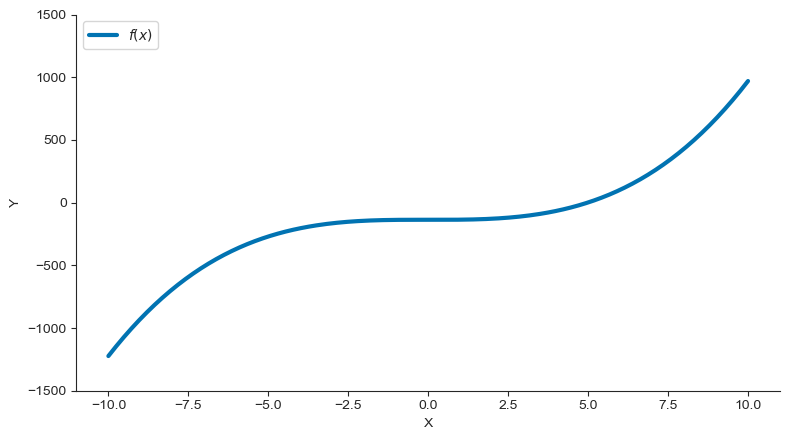

In [ ]:
# Plot f(x) w/ Seaborn
sns.set_palette(palette='colorblind')

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.set_style('ticks')
sns.lineplot(data=df, x='x', y='$f(x)$', 
             label='$f(x)$', linewidth=3, ax=ax)
sns.despine()
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_ylim(-1500, 1500)
ax.legend(loc='upper left')
fig.tight_layout()
fig.savefig(os.path.join(PATH_OUT, 'IrrErrSim01.png'))
plt.show()

In [ ]:
### Generate Irreducible Errors
rng = np.random.default_rng(23)
print(df.shape)
df['epsilon_small'] = rng.normal(0, 25, df.shape[0])
df['epsilon_medium'] = rng.normal(0, 250, df.shape[0])
df['epsilon_large'] = rng.normal(0, 5000, df.shape[0])

(250, 2)


In [ ]:
### Calculate & Plot Datapoints
df['y_small'] = df['$f(x)$'] + df['epsilon_small']
df['y_medium'] = df['$f(x)$'] + df['epsilon_medium']
df['y_large'] = df['$f(x)$'] + df['epsilon_large']

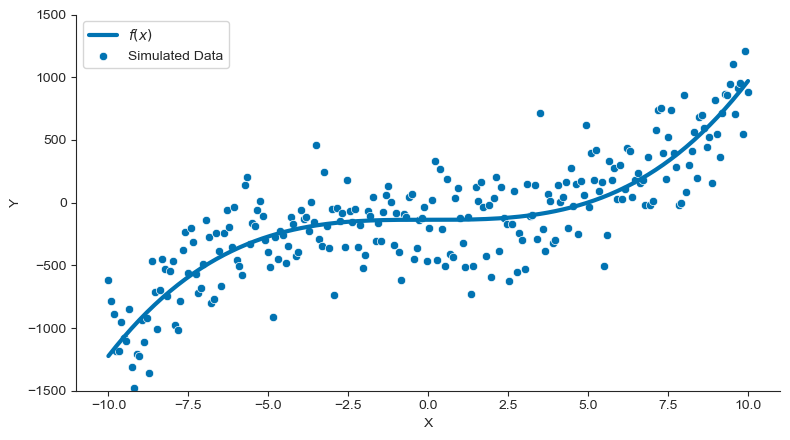

In [ ]:
# Medium Variance w/ f(x)
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.set_style('ticks')
sns.lineplot(data=df, x='x', y='$f(x)$', 
             label='$f(x)$', linewidth=3, ax=ax)
sns.scatterplot(data=df, x='x', y='y_medium',
                label='Simulated Data', ax=ax)
sns.despine()
#ax.set_title('Medium Variance Irreducible Errors', size=14)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_ylim(-1500, 1500)
ax.legend(loc='upper left')
fig.tight_layout()
fig.savefig(os.path.join(PATH_OUT, 'IrrErrSim02.png'))
plt.show()